
# Thesis-Ready Multimodal Sentiment Analysis
## Uncertainty-Aware Co-Attention + Evidential Deep Learning (EDL)

Dataset:
- `D:/MVSA_SINGLE`


In [1]:

# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"


    # =========================
    # EARLY STOPPING
    # =========================
    PATIENCE = 8

    # =========================
    # SPLIT
    # =========================
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda"


In [2]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=',')
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [3]:
# ============================================================
# CELL 3: IMPORTS & SEED
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings, random, os, copy

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device(CFG.DEVICE if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [4]:
# ============================================================
# CELL 4: DATASET & DATALOADER
# ============================================================

# --- Hyperparameters ---
class HP:
    PROJ_DIM = 128           # Reduced: 256→128 to limit capacity on small dataset
    BACKBONE_LR = 1e-6       # Reduced: 2e-5→1e-6 to prevent backbone overfitting
    HEAD_LR = 5e-4           # Reduced: 1e-3→5e-4 for smoother convergence
    LR_DECAY = 0.85          # Layerwise LR decay factor for BERT
    WEIGHT_DECAY = 0.05      # Increased: 0.01→0.05 for stronger L2 regularization
    BATCH_SIZE = 16
    MAX_EPOCHS = 50
    KL_ANNEALING_EPOCHS = 10  # KL regularizer kicks in earlier
    FOCAL_GAMMA = 2.0        # Ignore easy samples harder
    DROPOUT = 0.5            # Stronger regularization
    GRAD_CLIP_NORM = 1.0
    EARLY_STOP_PATIENCE = 10
    BACKBONE_FREEZE_EPOCHS = 8  # Extended: 3→8 to prevent early memorization
    MAX_TEXT_LEN = 128
    NUM_CLASSES = 3
    IMG_SIZE = 224
    MIXUP_ALPHA = 0.4        # Mixup interpolation strength
    NEUTRAL_BOOST = 1.0      # Extra loss multiplier for neutral samples

# --- Train/Val/Test Split ---
train_df, test_df = train_test_split(
    df, test_size=CFG.TEST_SIZE, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
    random_state=42, stratify=train_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train label distribution:\n{train_df['label'].value_counts().sort_index()}")

# --- Fix 1: Inverse Sqrt Class Weights ---
# Effective number with beta=0.99 produced near-flat weights [0.99, 1.03, 0.99]
# Inverse sqrt gives more discriminative weights: neg≈0.88, neu≈1.50, pos≈0.63
class_counts = train_df["label"].value_counts().sort_index().values.astype(float)
weights = 1.0 / np.sqrt(class_counts)
class_weights = torch.tensor(
    weights / weights.sum() * HP.NUM_CLASSES, dtype=torch.float32
).to(device)
print(f"Class weights (inverse sqrt): {class_weights}")
print(f"  neg={class_weights[0]:.4f}, neu={class_weights[1]:.4f}, pos={class_weights[2]:.4f}")

# --- Image Transforms ---
train_transform = transforms.Compose([
    transforms.Resize((HP.IMG_SIZE + 32, HP.IMG_SIZE + 32)),
    transforms.RandomResizedCrop(HP.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((HP.IMG_SIZE, HP.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# --- Tokenizer ---
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# --- Dataset Class ---
def random_swap(words, n=1):
    words = words.split()
    if len(words) < 2: return " ".join(words)
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return " ".join(words)

def augment_text(text, prob=0.15):
    if random.random() < prob:
        return random_swap(text, n=1)
    return text

class MVSADataset(Dataset):
    def __init__(self, dataframe, transform, tokenizer, max_len=HP.MAX_TEXT_LEN, is_train=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Text ---
        text = str(row["text"]) if row["text"] else ""
        if hasattr(self, 'is_train') and self.is_train:
            text = augment_text(text, prob=0.15)
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # --- Image ---
        img_path = row["image_path"]
        try:
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, HP.IMG_SIZE, HP.IMG_SIZE)

        # --- Label ---
        label = torch.tensor(row["label"], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": label,
        }

# --- DataLoaders ---
train_dataset = MVSADataset(train_df, train_transform, tokenizer, is_train=True)
val_dataset = MVSADataset(val_df, val_transform, tokenizer)
test_dataset = MVSADataset(test_df, val_transform, tokenizer)

# --- Fix 2: WeightedRandomSampler to oversample minority classes ---
# Neutral (10%) gets 5.7× more samples, negative (30%) gets 2.0× more
from torch.utils.data import WeightedRandomSampler
_max_count = float(class_counts.max())  # = 1878 (positive)
label_to_sample_w = {
    0: _max_count / class_counts[0],  # neg: 1878/950 ≈ 1.98×
    1: _max_count / class_counts[1],  # neu: 1878/329 ≈ 5.71× oversample!
    2: 1.0,                           # pos: baseline
}
sample_weights = [label_to_sample_w[l] for l in train_df["label"].values]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True
)

train_loader = DataLoader(
    train_dataset, batch_size=HP.BATCH_SIZE,
    sampler=sampler,  # replaces shuffle=True
    num_workers=0, pin_memory=True, drop_last=False
)
val_loader = DataLoader(val_dataset, batch_size=HP.BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=HP.BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"\nDataLoaders ready. Train batches: {len(train_loader)}")
print(f"WeightedRandomSampler: neg×{label_to_sample_w[0]:.1f}, neu×{label_to_sample_w[1]:.1f}, pos×{label_to_sample_w[2]:.1f}")


Train: 3157 | Val: 677 | Test: 677
Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64
Class weights (inverse sqrt): tensor([0.8796, 1.4947, 0.6256], device='cuda:0')
  neg=0.8796, neu=1.4947, pos=0.6256



DataLoaders ready. Train batches: 198
WeightedRandomSampler: neg×2.0, neu×5.7, pos×1.0


In [5]:
# ============================================================
# CELL 5: MODEL ARCHITECTURE — UA-EDL-CoAttn v3
# ============================================================

# ----- Fix 3: Attention Pooling (replaces mean pool & CLS) -----
class AttentionPool(nn.Module):
    """
    Learned attention pooling over a sequence.
    Focuses on the most sentiment-relevant regions/tokens.
    Replaces mean pooling (which averages out sentiment signal).
    """
    def __init__(self, dim):
        super().__init__()
        self.attn_w = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        # x: (B, N, d)
        scores = self.attn_w(x)             # (B, N, 1)
        weights = F.softmax(scores, dim=1)  # (B, N, 1) — softmax over sequence
        return (weights * x).sum(dim=1)     # (B, d) — weighted sum


# ----- Stage 4: Dempster's Combination Rule -----
class DempsterCombination(nn.Module):
    """Combine multiple Dirichlet distributions via Dempster's rule."""
    def __init__(self, num_classes):
        super().__init__()
        self.K = num_classes

    def _combine_two(self, alpha1, alpha2):
        """Combine two Dirichlet parameter sets."""
        S1 = alpha1.sum(dim=1, keepdim=True)  # (B, 1)
        S2 = alpha2.sum(dim=1, keepdim=True)
        E1 = alpha1 - 1
        E2 = alpha2 - 1
        b1 = E1 / S1.expand_as(E1)
        b2 = E2 / S2.expand_as(E2)
        u1 = self.K / S1  # (B, 1)
        u2 = self.K / S2

        # Conflict coefficient
        bb = torch.bmm(b1.unsqueeze(2), b2.unsqueeze(1))  # (B, K, K)
        bb_sum = bb.sum(dim=(1, 2))                         # (B,)
        bb_diag = torch.diagonal(bb, dim1=-2, dim2=-1).sum(-1)  # (B,)
        C = (bb_sum - bb_diag).unsqueeze(1)                 # (B, 1)

        # Combined belief & uncertainty
        b_comb = (b1 * b2 + b1 * u2.expand_as(b1) + b2 * u1.expand_as(b2)) \
                 / (1 - C).expand_as(b1).clamp(min=1e-8)
        u_comb = (u1 * u2) / (1 - C).clamp(min=1e-8)       # (B, 1)

        # Back to Dirichlet params
        S_comb = self.K / u_comb.clamp(min=1e-8)
        e_comb = b_comb * S_comb.expand_as(b_comb)
        alpha_comb = e_comb + 1
        return alpha_comb

    def forward(self, alpha_list):
        """Combine a list of Dirichlet parameter tensors."""
        alpha = alpha_list[0]
        for i in range(1, len(alpha_list)):
            alpha = self._combine_two(alpha, alpha_list[i])
        return alpha


# ----- Stage 2: Co-Attention -----
class CoAttention(nn.Module):
    """Bidirectional co-attention between text and image features."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.W_a = nn.Linear(dim, dim, bias=False)  # text→image
        self.W_b = nn.Linear(dim, dim, bias=False)  # image→text
        self.scale = dim ** 0.5
        self.dropout = nn.Dropout(dropout)

    def forward(self, H_t, H_v, text_mask=None):
        """
        H_t: (B, m, d) — text features
        H_v: (B, n, d) — image features (n=49 for ResNet)
        text_mask: (B, m) — 1 for real tokens, 0 for padding
        """
        # Text-guided visual attention: Q=text, K=V=image
        Q_t = self.W_a(H_t)                              # (B, m, d)
        scores_t2v = torch.bmm(Q_t, H_v.transpose(1, 2)) / self.scale  # (B, m, n)
        A_t2v = self.dropout(F.softmax(scores_t2v, dim=-1))
        H_v_prime = torch.bmm(A_t2v.transpose(1, 2), H_t)  # (B, n, d)

        # Image-guided textual attention: Q=image, K=V=text
        Q_v = self.W_b(H_v)                              # (B, n, d)
        scores_v2t = torch.bmm(Q_v, H_t.transpose(1, 2)) / self.scale  # (B, n, m)
        if text_mask is not None:
            mask = text_mask.unsqueeze(1).expand_as(scores_v2t)  # (B, n, m)
            scores_v2t = scores_v2t.masked_fill(mask == 0, -1e9)
        A_v2t = self.dropout(F.softmax(scores_v2t, dim=-1))
        H_t_prime = torch.bmm(A_v2t.transpose(1, 2), H_v)  # (B, m, d)

        return H_t_prime, H_v_prime


# ----- Stage 3: EDL Head -----
class EDLHead(nn.Module):
    """Evidential Deep Learning head: features → evidence → Dirichlet."""
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        evidence = F.relu(self.mlp(x))         # (B, K), non-negative
        alpha = evidence + 1                    # (B, K), >= 1
        S = alpha.sum(dim=1, keepdim=True)      # (B, 1)
        uncertainty = self.mlp[0].in_features    # just use K
        uncertainty = alpha.shape[1] / S        # u = K / S
        return alpha, uncertainty


# ----- Full Model -----
class UAEDLCoAttn(nn.Module):
    """
    Uncertainty-Aware EDL Co-Attention Model (v2).
    3 parallel EDL heads + Dempster's combination.
    """
    def __init__(self, num_classes=3, proj_dim=256, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.proj_dim = proj_dim

        # --- Stage 1a: Image backbone (ResNet-50) ---
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.image_backbone = nn.Sequential(*list(resnet.children())[:-2])  # Remove avgpool+fc
        self.image_proj = nn.Sequential(
            nn.Linear(2048, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Stage 1b: Text backbone (BERT) ---
        self.text_backbone = BertModel.from_pretrained("bert-base-uncased")
        self.text_proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Stage 2: Co-Attention ---
        self.co_attention = CoAttention(proj_dim, dropout=dropout)

        # --- Stage 3a: Image EDL Head (from H_v, BEFORE co-attention) ---
        self.image_edl_head = EDLHead(proj_dim, proj_dim, num_classes, dropout)

        # --- Stage 3b: Co-Attention EDL Head (from H_v' + H_t', AFTER co-attention) ---
        self.coattn_edl_head = EDLHead(proj_dim * 2, proj_dim, num_classes, dropout)

        # --- Stage 3c: Text EDL Head (from H_t, BEFORE co-attention) ---
        self.text_edl_head = EDLHead(proj_dim, proj_dim, num_classes, dropout)

        # --- Stage 4: Dempster's Combination ---
        self.dempster = DempsterCombination(num_classes)

        # --- Fix 3: Attention Pooling (replaces mean pool / CLS) ---
        self.image_attn_pool = AttentionPool(proj_dim)
        self.text_attn_pool  = AttentionPool(proj_dim)

    def extract_image_features(self, images):
        """Stage 1a: Image → H_v (B, 49, d)"""
        feat = self.image_backbone(images)           # (B, 2048, 7, 7)
        B, C, H, W = feat.shape
        feat = feat.view(B, C, H * W).permute(0, 2, 1)  # (B, 49, 2048)
        H_v = self.image_proj(feat)                  # (B, 49, d)
        return H_v

    def extract_text_features(self, input_ids, attention_mask):
        """Stage 1b: Text → H_t (B, m, d)"""
        outputs = self.text_backbone(
            input_ids=input_ids, attention_mask=attention_mask
        )
        H_t_raw = outputs.last_hidden_state          # (B, m, 768)
        H_t = self.text_proj(H_t_raw)                # (B, m, d)
        return H_t

    def forward(self, input_ids, attention_mask, images):
        # === Stage 1: Feature Extraction ===
        H_v = self.extract_image_features(images)     # (B, 49, d)
        H_t = self.extract_text_features(input_ids, attention_mask)  # (B, m, d)

        # === Stage 2: Co-Attention ===
        H_t_prime, H_v_prime = self.co_attention(H_t, H_v, text_mask=attention_mask)

        # === Stage 3a: Image Head (BEFORE co-attention → unimodal) ===
        # Fix 3: Attention pool instead of mean pool
        h_v_pool = self.image_attn_pool(H_v)         # (B, d)
        alpha_v, u_v = self.image_edl_head(h_v_pool)

        # === Stage 3b: Co-Attention Head (AFTER co-attention → cross-modal) ===
        # Fix 3: Attention pool for both attended features
        h_v_att = self.image_attn_pool(H_v_prime)    # (B, d)
        h_t_att = self.text_attn_pool(H_t_prime)     # (B, d)
        h_cross = torch.cat([h_v_att, h_t_att], dim=-1)  # (B, 2d)
        alpha_c, u_c = self.coattn_edl_head(h_cross)

        # === Stage 3c: Text Head (BEFORE co-attention → unimodal) ===
        # Fix 3: Attention pool instead of CLS token
        h_t_cls = self.text_attn_pool(H_t)           # (B, d)
        alpha_t, u_t = self.text_edl_head(h_t_cls)

        # === Stage 4: Dempster's Combination ===
        # Unimodal first, then cross-modal
        alpha_f = self.dempster([alpha_t, alpha_v, alpha_c])

        return {
            "alpha_t": alpha_t, "u_t": u_t,
            "alpha_v": alpha_v, "u_v": u_v,
            "alpha_c": alpha_c, "u_c": u_c,
            "alpha_f": alpha_f,
        }

# --- Instantiate ---
model = UAEDLCoAttn(
    num_classes=HP.NUM_CLASSES,
    proj_dim=HP.PROJ_DIM,
    dropout=HP.DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6028.91it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 133,467,467
Trainable params: 133,467,467


In [6]:
# ============================================================
# CELL 6: LOSS FUNCTIONS — Focal-EDL + KL Regularizer
# ============================================================

def focal_edl_loss(alpha, y_onehot, class_weights, gamma=2.0):
    """
    Focal-weighted EDL loss (SSE Bayes Risk) with neutral-aware boost.
    - class_weights: static per-class weight (inverse sqrt)
    - focal: dynamic per-sample weight based on prediction confidence
    - neutral_boost: Fix 4 — extra 3× penalty for neutral samples
    """
    S = alpha.sum(dim=1, keepdim=True)             # (B, 1)
    p_hat = alpha / S                               # (B, K)

    # Focal weight: (1 - p_correct)^gamma
    p_correct = (p_hat * y_onehot).sum(dim=1, keepdim=True)  # (B, 1)
    focal_w = (1 - p_correct.detach()) ** gamma     # (B, 1)

    # EDL components
    err = (y_onehot - p_hat) ** 2                   # (B, K)
    var = p_hat * (1 - p_hat) / (S + 1)             # (B, K)

    # Fix 4: Neutral-aware boost — 3× extra penalty for neutral samples
    # neutral_mask = 1 for neutral samples, 0 otherwise
    neutral_mask = y_onehot[:, 1:2]                # (B, 1) — class index 1 = neutral
    sample_boost = 1.0 + HP.NEUTRAL_BOOST * neutral_mask  # (B, 1): 3× for neutral, 1× others

    # Combined: focal × neutral_boost × class_weight (per-class)
    # For neutral: 1.0 × 3.0 × 1.50 = 4.50× total vs positive: 1.0 × 1.0 × 0.63 = 0.63×
    loss = focal_w * sample_boost * class_weights.unsqueeze(0) * (err + var)  # (B, K)

    return loss.sum(dim=1).mean()


def kl_divergence_reg(alpha, y_onehot, epoch, annealing_epochs=10):
    """
    KL divergence regularizer: penalizes misleading evidence.
    Pushes evidence for WRONG classes toward zero.
    """
    K = alpha.shape[1]
    lambda_t = min(1.0, epoch / annealing_epochs)

    # Remove evidence from correct class (don't penalize it)
    alpha_tilde = y_onehot + (1 - y_onehot) * alpha  # correct class → 1

    S_tilde = alpha_tilde.sum(dim=1, keepdim=True)    # (B, 1)

    # KL[Dir(alpha_tilde) || Dir(1, 1, ..., 1)]
    ln_B = torch.lgamma(S_tilde) - torch.lgamma(alpha_tilde).sum(dim=1, keepdim=True)
    ln_B_uni = torch.lgamma(torch.ones(1, K, device=alpha.device)).sum() \
             - torch.lgamma(torch.tensor(float(K), device=alpha.device))

    dg0 = torch.digamma(S_tilde)
    dg1 = torch.digamma(alpha_tilde)

    kl = ((alpha_tilde - 1) * (dg1 - dg0)).sum(dim=1, keepdim=True) + ln_B + ln_B_uni

    return lambda_t * kl.mean()


def head_loss(alpha, y_onehot, class_weights, epoch, gamma=1.0, kl_epochs=10):
    """Combined loss for a single EDL head."""
    return focal_edl_loss(alpha, y_onehot, class_weights, gamma) \
         + kl_divergence_reg(alpha, y_onehot, epoch, kl_epochs)


def total_loss(outputs, y_onehot, class_weights, epoch, max_epoch,
               gamma=1.0, kl_epochs=10, outputs2=None):
    """
    Total multi-task loss with dynamic auxiliary blending.
    L = w_aux * (L_text + L_image + L_coattn) + 1.0 * L_final + rdrop
    If outputs2 is provided, adds R-Drop consistency regularization.
    """
    L_t = head_loss(outputs["alpha_t"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_v = head_loss(outputs["alpha_v"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_c = head_loss(outputs["alpha_c"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_f = head_loss(outputs["alpha_f"], y_onehot, class_weights, epoch, gamma, kl_epochs)

    # Dynamic auxiliary weight: strong early (regularize), weak late (fine-tune)
    w_aux = max(0.1, 1.0 - epoch / max_epoch)

    loss = w_aux * (L_t + L_v + L_c) + 1.0 * L_f

    # R-Drop consistency regularization
    if outputs2 is not None:
        def rdrop_kl(a1, a2):
            s1, s2 = a1.sum(1, keepdim=True), a2.sum(1, keepdim=True)
            p1, p2 = a1 / s1, a2 / s2
            kl_12 = (p1 * (p1.log() - p2.log())).sum(1).mean()
            kl_21 = (p2 * (p2.log() - p1.log())).sum(1).mean()
            return (kl_12 + kl_21) / 2

        rdrop = rdrop_kl(outputs["alpha_f"], outputs2["alpha_f"])
        loss = loss + 1.5 * rdrop

    return loss


In [7]:
# ============================================================
# CELL 7: TRAINING & EVALUATION FUNCTIONS
# ============================================================

def set_backbone_grad(model, requires_grad):
    """Toggle backbone gradient computation (Partial freezing)."""
    for name, param in model.image_backbone.named_parameters():
        if name.startswith("7."):  # layer4
            param.requires_grad = requires_grad
        else:
            param.requires_grad = False
    for name, param in model.text_backbone.named_parameters():
        if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
            param.requires_grad = requires_grad
        else:
            param.requires_grad = False
def mixup_batch(images, y_onehot, alpha=0.4):
    """
    Mixup: interpolasi antar-sampel untuk augmentasi.
    Hanya untuk image — text tidak bisa di-mix (discrete tokens).
    """
    if alpha <= 0:
        return images, y_onehot

    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # Pastikan lam >= 0.5 (sample asli dominan)

    batch_size = images.size(0)
    index = torch.randperm(batch_size, device=images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_y = lam * y_onehot + (1 - lam) * y_onehot[index]

    return mixed_images, mixed_y


def train_one_epoch(model, loader, optimizer, class_weights, epoch, max_epoch):
    model.train()

    # Backbone freezing for first N epochs
    if epoch < HP.BACKBONE_FREEZE_EPOCHS:
        set_backbone_grad(model, False)
    else:
        set_backbone_grad(model, True)

    use_rdrop = epoch >= HP.BACKBONE_FREEZE_EPOCHS  # R-Drop only after unfreeze

    total_loss_val = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        y_onehot = F.one_hot(labels, HP.NUM_CLASSES).float()
        epsilon = 0.1
        y_onehot = y_onehot * (1 - epsilon) + (epsilon / HP.NUM_CLASSES)

        # Fix 5: Mixup augmentation (50% chance per batch, only after backbone unfreeze)
        use_mixup = (epoch >= HP.BACKBONE_FREEZE_EPOCHS) and (random.random() < 0.5)
        if use_mixup:
            images, y_onehot = mixup_batch(images, y_onehot, alpha=HP.MIXUP_ALPHA)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask, images)

        # R-Drop: second forward pass with different dropout masks
        outputs2 = None
        if use_rdrop:
            outputs2 = model(input_ids, attention_mask, images)

        loss = total_loss(
            outputs, y_onehot, class_weights,
            epoch, max_epoch,
            gamma=HP.FOCAL_GAMMA,
            kl_epochs=HP.KL_ANNEALING_EPOCHS,
            outputs2=outputs2
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HP.GRAD_CLIP_NORM)
        optimizer.step()

        # Predictions from final alpha
        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)

        total_loss_val += loss.item() * labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss_val / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, acc


@torch.no_grad()
def evaluate(model, loader, class_weights, epoch, max_epoch, return_details=False):
    model.eval()

    total_loss_val = 0
    all_preds, all_labels = [], []
    all_uncertainties = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        y_onehot = F.one_hot(labels, HP.NUM_CLASSES).float()
        epsilon = 0.1
        y_onehot = y_onehot * (1 - epsilon) + (epsilon / HP.NUM_CLASSES)

        outputs = model(input_ids, attention_mask, images)

        loss = total_loss(
            outputs, y_onehot, class_weights,
            epoch, max_epoch,
            gamma=HP.FOCAL_GAMMA,
            kl_epochs=HP.KL_ANNEALING_EPOCHS
        )

        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)
        u_f = HP.NUM_CLASSES / S_f.squeeze(1)

        total_loss_val += loss.item() * labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_uncertainties.extend(u_f.cpu().numpy())

    avg_loss = total_loss_val / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    acc = accuracy_score(all_labels, all_preds)

    metrics = {
        "loss": avg_loss,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": acc,
    }

    if return_details:
        metrics["preds"] = np.array(all_preds)
        metrics["labels"] = np.array(all_labels)
        metrics["uncertainties"] = np.array(all_uncertainties)

    return metrics


class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.best_model = None
        self.should_stop = False

    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


print("Training & evaluation functions defined.")


Training & evaluation functions defined.


In [8]:
# ============================================================
# CELL 8: TRAINING LOOP
# ============================================================

# --- Fix 6: Layerwise LR decay for BERT ---
def get_layerwise_lr_params(model, bert_base_lr=5e-6, lr_decay=0.85, head_lr=5e-4):
    """BERT layer-wise LR decay: lower layers get smaller LR."""
    params = []

    # BERT embeddings — smallest LR
    params.append({
        "params": model.text_backbone.embeddings.parameters(),
        "lr": bert_base_lr * (lr_decay ** 12)
    })

    # BERT encoder layers — gradual increase
    for i, layer in enumerate(model.text_backbone.encoder.layer):
        lr = bert_base_lr * (lr_decay ** (11 - i))
        params.append({"params": layer.parameters(), "lr": lr})

    # BERT pooler
    if model.text_backbone.pooler is not None:
        params.append({
            "params": model.text_backbone.pooler.parameters(),
            "lr": bert_base_lr
        })

    # ResNet — same backbone LR
    params.append({"params": model.image_backbone.parameters(), "lr": bert_base_lr})

    # All heads — higher LR
    for module in [model.text_proj, model.image_proj, model.co_attention,
                   model.text_edl_head, model.image_edl_head, model.coattn_edl_head,
                   model.image_attn_pool, model.text_attn_pool]:
        params.append({"params": module.parameters(), "lr": head_lr})

    return params

optimizer = torch.optim.AdamW(
    get_layerwise_lr_params(model, bert_base_lr=HP.BACKBONE_LR, lr_decay=HP.LR_DECAY, head_lr=HP.HEAD_LR),
    weight_decay=HP.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

early_stopping = EarlyStopping(patience=HP.EARLY_STOP_PATIENCE, min_delta=0.001)

# --- History ---
history = {
    "train_loss": [], "train_f1": [], "train_acc": [],
    "val_loss": [], "val_f1": [], "val_acc": [], "val_wf1": [],
}

# --- Training ---
print("=" * 60)
print("TRAINING START")
print("=" * 60)

for epoch in range(HP.MAX_EPOCHS):
    # Train
    train_loss, train_f1, train_acc = train_one_epoch(
        model, train_loader, optimizer, class_weights, epoch, HP.MAX_EPOCHS
    )

    # Validate
    val_metrics = evaluate(
        model, val_loader, class_weights, epoch, HP.MAX_EPOCHS
    )

    scheduler.step()

    # Log
    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_f1"].append(val_metrics["macro_f1"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_wf1"].append(val_metrics["weighted_f1"])

    freeze_str = "❄️ FROZEN" if epoch < HP.BACKBONE_FREEZE_EPOCHS else "🔥 FINE-TUNE"
    w_aux = max(0.1, 1.0 - epoch / HP.MAX_EPOCHS)

    print(f"Epoch {epoch+1:>3}/{HP.MAX_EPOCHS} | {freeze_str} | w_aux={w_aux:.2f} | "
          f"Train L={train_loss:.4f} F1={train_f1:.4f} | "
          f"Val L={val_metrics['loss']:.4f} F1={val_metrics['macro_f1']:.4f} "
          f"wF1={val_metrics['weighted_f1']:.4f} Acc={val_metrics['accuracy']:.4f}")

    # Early stopping (only after KL annealing is done)
    if epoch >= HP.KL_ANNEALING_EPOCHS:
        early_stopping(val_metrics["macro_f1"], model)
        if early_stopping.should_stop:
            print(f"\n⏹ Early stopping at epoch {epoch+1}. "
                  f"Best val Macro-F1: {early_stopping.best_score:.4f}")
            break

# Load best model
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)
    print("✅ Loaded best model weights.")
else:
    print("⚠️ No early stopping triggered, using last epoch weights.")

print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)


TRAINING START


Epoch   1/50 | ❄️ FROZEN | w_aux=1.00 | Train L=1.3115 F1=0.3742 | Val L=1.0223 F1=0.3286 wF1=0.4086 Acc=0.4032


Epoch   2/50 | ❄️ FROZEN | w_aux=0.98 | Train L=1.4002 F1=0.5437 | Val L=1.0284 F1=0.5867 wF1=0.6449 Acc=0.6381


Epoch   3/50 | ❄️ FROZEN | w_aux=0.96 | Train L=1.2125 F1=0.6620 | Val L=1.0783 F1=0.5762 wF1=0.6505 Acc=0.6248


Epoch   4/50 | ❄️ FROZEN | w_aux=0.94 | Train L=1.1747 F1=0.7008 | Val L=1.0772 F1=0.5807 wF1=0.6597 Acc=0.6322


...

Epoch  30/50 | 🔥 FINE-TUNE | w_aux=0.42 | Train L=0.4907 F1=0.8802 | Val L=0.6724 F1=0.6171 wF1=0.6973 Acc=0.6869


Epoch  31/50 | 🔥 FINE-TUNE | w_aux=0.40 | Train L=0.5044 F1=0.8506 | Val L=0.6266 F1=0.6391 wF1=0.7210 Acc=0.7134


Epoch  32/50 | 🔥 FINE-TUNE | w_aux=0.38 | Train L=0.4970 F1=0.8535 | Val L=0.6647 F1=0.5832 wF1=0.6818 Acc=0.6662


Epoch  33/50 | 🔥 FINE-TUNE | w_aux=0.36 | Train L=0.4633 F1=0.8697 | Val L=0.6586 F1=0.5927 wF1=0.6878 Acc=0.6721


Epoch  34/50 | 🔥 FINE-TUNE | w_aux=0.34 | Train L=0.4376 F1=0.8841 | Val L=0.6046 F1=0.6215 wF1=0.7092 Acc=0.7001

⏹ Early stopping at epoch 34. Best val Macro-F1: 0.6482
✅ Loaded best model weights.
TRAINING COMPLETE


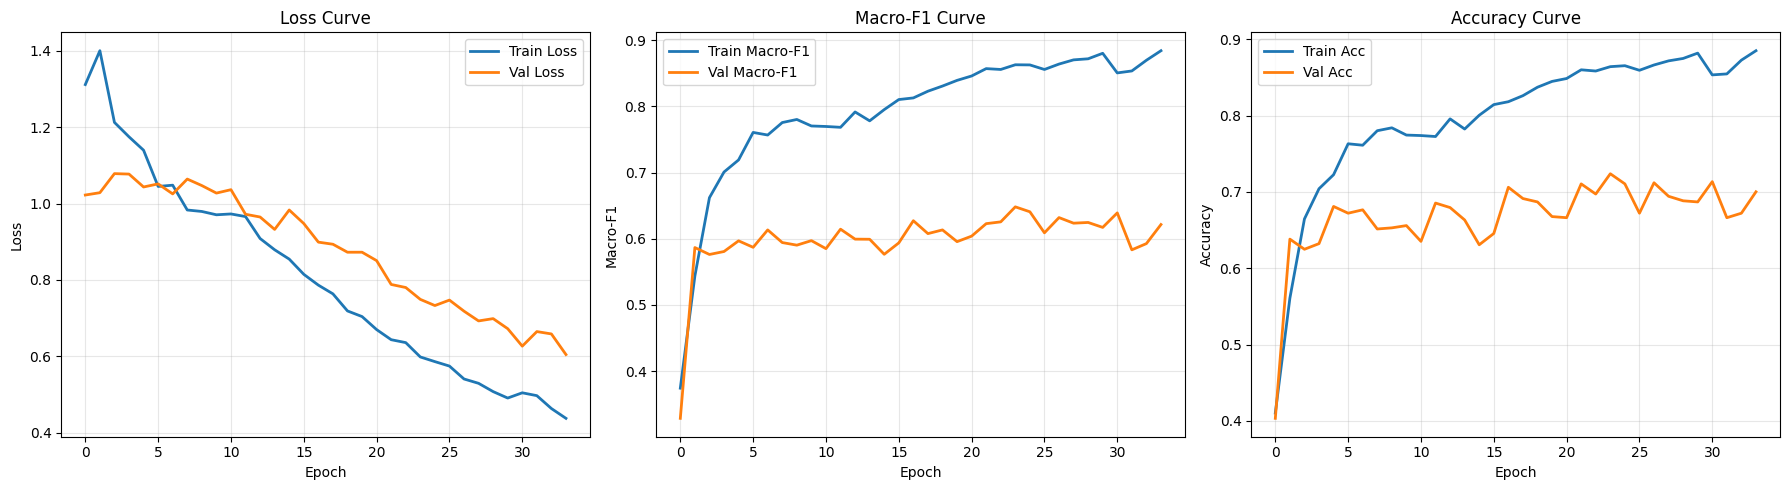

In [9]:
# ============================================================
# CELL 9: TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Macro-F1
axes[1].plot(history["train_f1"], label="Train Macro-F1", linewidth=2)
axes[1].plot(history["val_f1"], label="Val Macro-F1", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Macro-F1 Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[2].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy Curve")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TEST SET RESULTS
Accuracy:    0.6913
Macro-F1:    0.6183
Weighted-F1: 0.6966

              precision    recall  f1-score   support

    negative     0.6063    0.6569    0.6306       204
     neutral     0.4118    0.5000    0.4516        70
    positive     0.8059    0.7419    0.7726       403

    accuracy                         0.6913       677
   macro avg     0.6080    0.6329    0.6183       677
weighted avg     0.7050    0.6913    0.6966       677



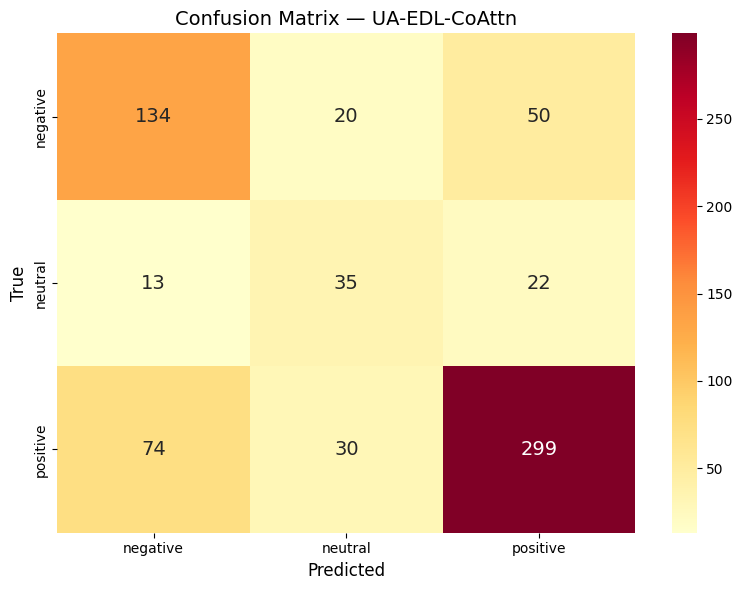

In [10]:
# ============================================================
# CELL 10: TEST SET EVALUATION
# ============================================================

test_metrics = evaluate(
    model, test_loader, class_weights,
    epoch=HP.MAX_EPOCHS, max_epoch=HP.MAX_EPOCHS,
    return_details=True
)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"Macro-F1:    {test_metrics['macro_f1']:.4f}")
print(f"Weighted-F1: {test_metrics['weighted_f1']:.4f}")
print()

# Classification Report
print(classification_report(
    test_metrics["labels"], test_metrics["preds"],
    target_names=["negative", "neutral", "positive"],
    digits=4
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — UA-EDL-CoAttn", fontsize=14)
plt.tight_layout()
plt.show()


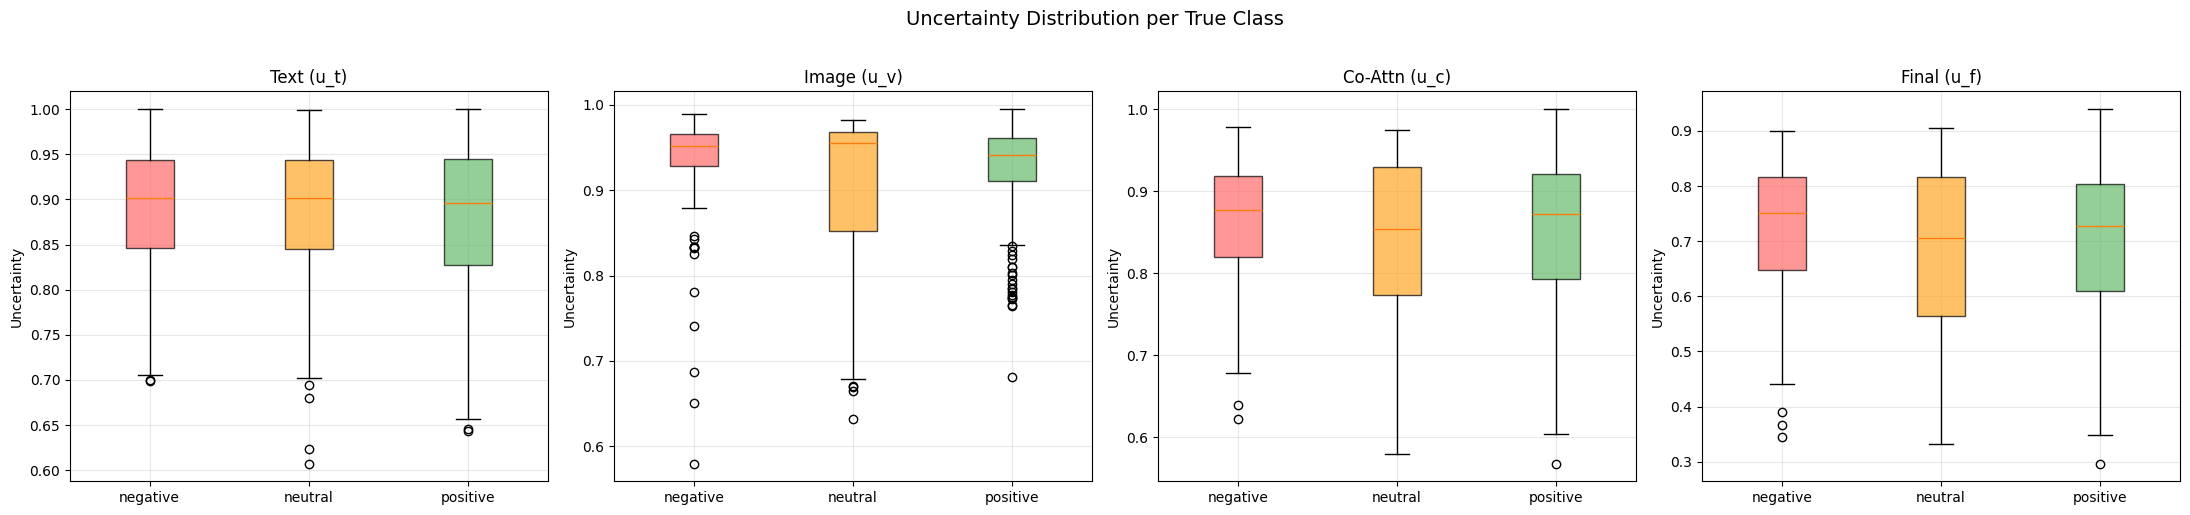

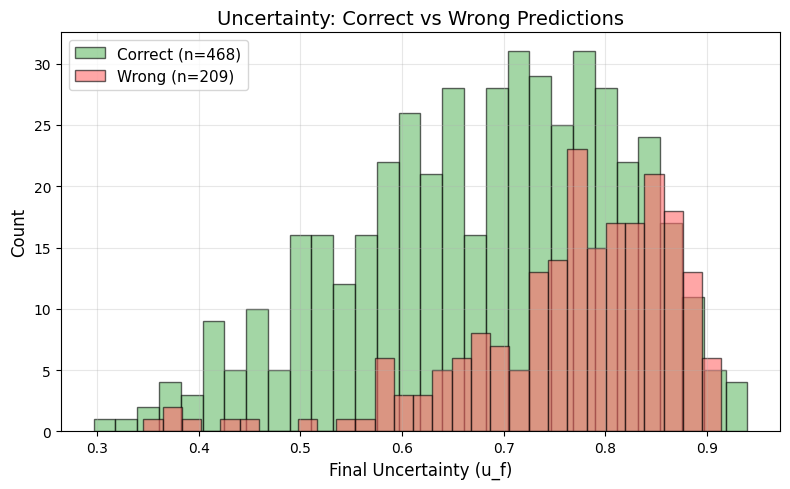

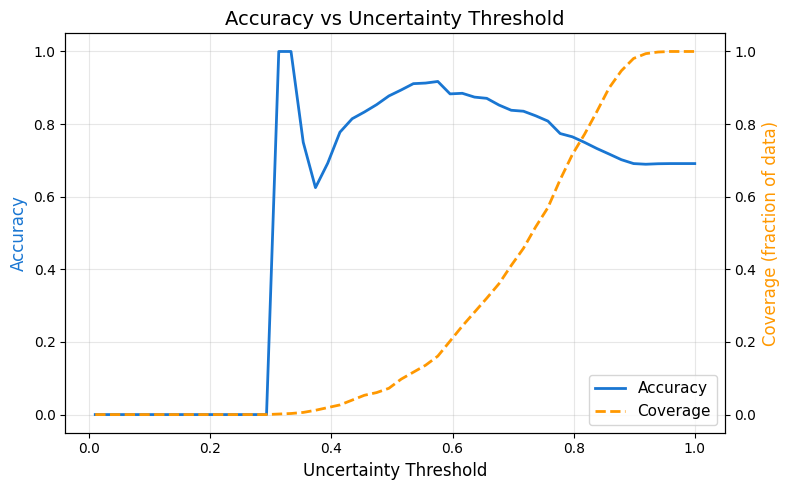

UNCERTAINTY STATISTICS

Text (u_t):
    negative: mean=0.8875, median=0.9013, std=0.0698
     neutral: mean=0.8799, median=0.9013, std=0.0884
    positive: mean=0.8778, median=0.8960, std=0.0820

Image (u_v):
    negative: mean=0.9380, median=0.9523, std=0.0519
     neutral: mean=0.9004, median=0.9551, std=0.0952
    positive: mean=0.9281, median=0.9417, std=0.0469

Co-Attn (u_c):
    negative: mean=0.8635, median=0.8774, std=0.0707
     neutral: mean=0.8400, median=0.8539, std=0.0972
    positive: mean=0.8495, median=0.8716, std=0.0857

Final (u_f):
    negative: mean=0.7278, median=0.7519, std=0.1137
     neutral: mean=0.6790, median=0.7065, std=0.1559
    positive: mean=0.7024, median=0.7272, std=0.1320

Correct predictions — mean u_f: 0.6816
Wrong predictions   — mean u_f: 0.7661


In [11]:
# ============================================================
# CELL 11: UNCERTAINTY ANALYSIS
# ============================================================

@torch.no_grad()
def collect_uncertainty_details(model, loader):
    """Collect per-head uncertainties for analysis."""
    model.eval()
    results = {"u_t": [], "u_v": [], "u_c": [], "u_f": [],
               "preds": [], "labels": [], "correct": []}

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask, images)

        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)
        u_f = HP.NUM_CLASSES / S_f.squeeze(1)

        results["u_t"].extend(outputs["u_t"].squeeze(1).cpu().numpy())
        results["u_v"].extend(outputs["u_v"].squeeze(1).cpu().numpy())
        results["u_c"].extend(outputs["u_c"].squeeze(1).cpu().numpy())
        results["u_f"].extend(u_f.cpu().numpy())
        results["preds"].extend(preds.cpu().numpy())
        results["labels"].extend(labels.cpu().numpy())
        results["correct"].extend((preds == labels).cpu().numpy())

    return {k: np.array(v) for k, v in results.items()}

unc_data = collect_uncertainty_details(model, test_loader)

# --- Plot 1: Uncertainty Distribution per True Class ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
head_names = ["Text (u_t)", "Image (u_v)", "Co-Attn (u_c)", "Final (u_f)"]
head_keys = ["u_t", "u_v", "u_c", "u_f"]
class_names = ["negative", "neutral", "positive"]

for ax, key, name in zip(axes, head_keys, head_names):
    data_by_class = [unc_data[key][unc_data["labels"] == c] for c in range(3)]
    bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
    colors = ["#FF6B6B", "#FFA726", "#66BB6A"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Uncertainty")
    ax.grid(True, alpha=0.3)

plt.suptitle("Uncertainty Distribution per True Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Uncertainty vs Correctness ---
fig, ax = plt.subplots(figsize=(8, 5))
correct_u = unc_data["u_f"][unc_data["correct"] == 1]
wrong_u = unc_data["u_f"][unc_data["correct"] == 0]

ax.hist(correct_u, bins=30, alpha=0.6, label=f"Correct (n={len(correct_u)})",
        color="#66BB6A", edgecolor="black")
ax.hist(wrong_u, bins=30, alpha=0.6, label=f"Wrong (n={len(wrong_u)})",
        color="#FF6B6B", edgecolor="black")
ax.set_xlabel("Final Uncertainty (u_f)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Uncertainty: Correct vs Wrong Predictions", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Accuracy vs Uncertainty Threshold ---
thresholds = np.linspace(0.01, 1.0, 50)
accs_at_threshold = []
coverage = []
for t in thresholds:
    mask = unc_data["u_f"] <= t
    if mask.sum() > 0:
        accs_at_threshold.append(accuracy_score(
            unc_data["labels"][mask], unc_data["preds"][mask]
        ))
        coverage.append(mask.mean())
    else:
        accs_at_threshold.append(0)
        coverage.append(0)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds, accs_at_threshold, color="#1976D2", linewidth=2, label="Accuracy")
ax2.plot(thresholds, coverage, color="#FF9800", linewidth=2, linestyle="--", label="Coverage")
ax1.set_xlabel("Uncertainty Threshold", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12, color="#1976D2")
ax2.set_ylabel("Coverage (fraction of data)", fontsize=12, color="#FF9800")
ax1.set_title("Accuracy vs Uncertainty Threshold", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Stats ---
print("=" * 60)
print("UNCERTAINTY STATISTICS")
print("=" * 60)
for key, name in zip(head_keys, head_names):
    print(f"\n{name}:")
    for c, cn in enumerate(class_names):
        vals = unc_data[key][unc_data["labels"] == c]
        print(f"  {cn:>10}: mean={vals.mean():.4f}, median={np.median(vals):.4f}, std={vals.std():.4f}")
print(f"\nCorrect predictions — mean u_f: {correct_u.mean():.4f}")
print(f"Wrong predictions   — mean u_f: {wrong_u.mean():.4f}")


In [12]:
# ============================================================
# CELL 12: SAVE MODEL
# ============================================================

save_path = os.path.join(os.path.dirname(CFG.ROOT_DIR), "ua_edl_coattn_best.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "hyperparameters": {
        "proj_dim": HP.PROJ_DIM,
        "num_classes": HP.NUM_CLASSES,
        "dropout": HP.DROPOUT,
    },
    "class_weights": class_weights.cpu(),
    "history": history,
    "best_val_macro_f1": early_stopping.best_score,
    "test_metrics": {
        "accuracy": test_metrics["accuracy"],
        "macro_f1": test_metrics["macro_f1"],
        "weighted_f1": test_metrics["weighted_f1"],
    },
}, save_path)

print(f"✅ Model saved to: {save_path}")
print(f"   Best Val Macro-F1: {early_stopping.best_score:.4f}")
print(f"   Test Macro-F1:     {test_metrics['macro_f1']:.4f}")


✅ Model saved to: D:/ua_edl_coattn_best.pt
   Best Val Macro-F1: 0.6482
   Test Macro-F1:     0.6183
